In [9]:
import sys
import os

BASE_DIR = os.path.dirname(os.getcwd())

sys.path.append(os.path.join(BASE_DIR, "src"))

In [10]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = os.path.dirname(os.getcwd())

model_path = os.path.join(BASE_DIR, "artifacts", "best_model.pkl")
preprocessor_path = os.path.join(BASE_DIR, "artifacts", "preprocessing_pipeline.pkl")

rf_model = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

In [12]:
feature_names = preprocessor.named_steps["preprocessing"].get_feature_names_out()

feature_names

array(['cat__Type_H', 'cat__Type_L', 'cat__Type_M',
       'num__Air temperature [K]', 'num__Process temperature [K]',
       'num__Rotational speed [rpm]', 'num__Torque [Nm]',
       'num__Tool wear [min]', 'num__Temp_diff', 'num__Power'],
      dtype=object)

In [13]:
len(feature_names)

10

In [14]:
import pandas as pd

data_path = os.path.join(BASE_DIR, "data", "processed", "binary_full_dataset.csv")

df = pd.read_csv(data_path)

X = df.drop(columns=["Machine failure"])

X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


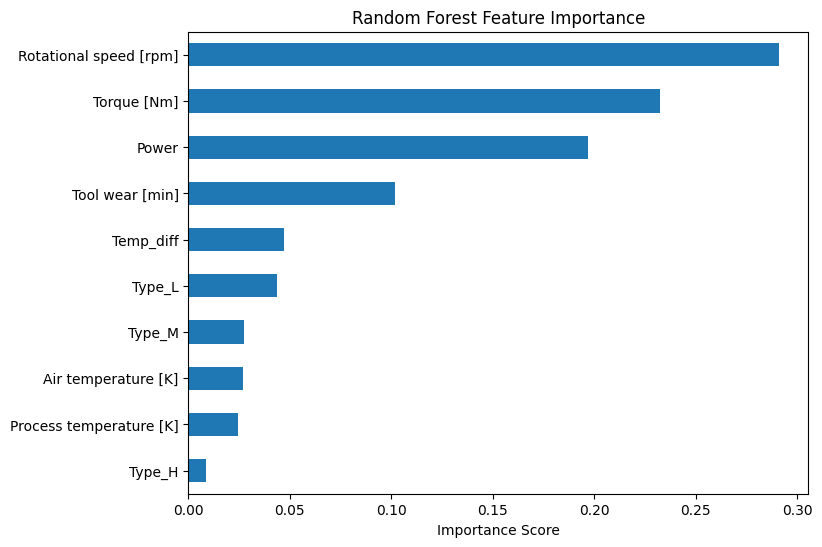

In [18]:
# Clean feature names
clean_names = [name.split("__")[-1] for name in feature_names]

# Create series
feat_imp = pd.Series(importances, index=clean_names)

# Sort values
feat_imp = feat_imp.sort_values()

# Create figure
plt.figure(figsize=(8,6))
feat_imp.plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

# Ensure directory exists
os.makedirs("../results/figures", exist_ok=True)

# Save figure
plt.savefig("../results/figures/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()